In [1]:
# min-max scaling 
def gray_embedding(x):
    result = []
    max = x.max()
    min = x.min()
    for i in range(len(x)):
        z = ((x[i]-min)/(max-min))*255
        result.append(z)
    return result

In [2]:
import pandas as pd 

raw_data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\scenarioA_raw.csv")

In [4]:
embed_data = raw_data.copy()

In [5]:
X_cols = [f"X{i}" for i in range(1, 51)]

embed_data[X_cols] = embed_data[X_cols].apply(gray_embedding)

In [6]:
# y從大排到小
embed_data = embed_data.sort_values("Y", ascending=False).reset_index(drop=True)

In [9]:
# 根據變數與Y之間的相關性排序
corr = embed_data.corr(numeric_only=True)["Y"].drop("Y").abs()

order = corr.sort_values(ascending=False).index

embed_data = embed_data[ list(order) + ["Y"] ]

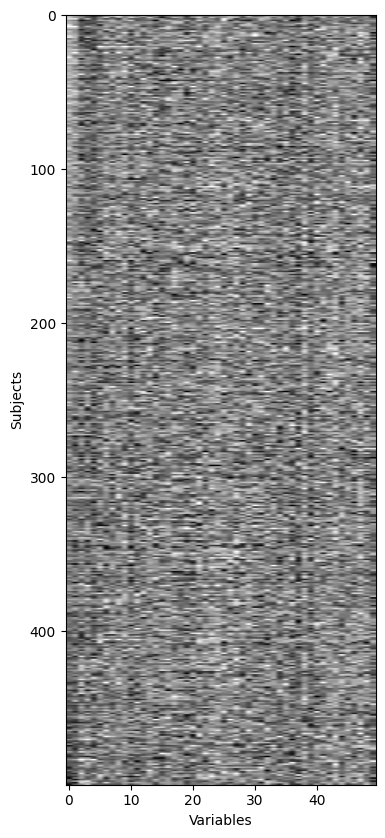

In [10]:
import matplotlib.pyplot as plt

image = embed_data.iloc[:,:-1].values

plt.figure(figsize=(4,10))

plt.imshow(
    image,
    cmap="gray",
    aspect="auto",
    vmin=0,
    vmax=255
)

plt.xlabel("Variables")
plt.ylabel("Subjects")

plt.show()

In [11]:
import statsmodels.api as sm

# 自變數
X = embed_data.iloc[:,:-1]

# 加入截距項
X = sm.add_constant(X)

# 建立模型
model = sm.OLS(embed_data["Y"], X).fit()

# 查看結果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     85.80
Date:                  週二, 07 七月 2026   Prob (F-statistic):          2.51e-198
Time:                        13:25:09   Log-Likelihood:                -697.24
No. Observations:                 500   AIC:                             1496.
Df Residuals:                     449   BIC:                             1711.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.6833      0.608     -9.340      0.0

In [ ]:
# embed_data.to_csv(r"C:\Users\USER\Desktop\碩論\程式碼\scenarioA_embed.csv"  , index = False)